# Entregable 3 — EDA Parte 2: Calidad · Distribuciones · Riesgos · Accionables
## Detección de variaciones en el valor unitario · Exportaciones peruanas SUNAT

**Autor:** Said Leonardo Uceda Paredes &nbsp;|&nbsp; **Programa:** Maestría en IA — UNI &nbsp;|&nbsp; **Sprint 1 · Semana 3** &nbsp;|&nbsp; Mayo 2026

---
| Sección | Contenido |
|---------|----------|
| 1 | **Calidad** — Nulos · Tipos · Rangos · Duplicados |
| 2 | **Distribuciones y relaciones** — Histogramas · Balance · Correlaciones |
| 3 | **Riesgos** — Desbalance · Leakage · Drift · Sesgo |
| 4 | **Conclusiones accionables** — Mínimo 2 decisiones concretas |

In [1]:
import logging
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from sqlalchemy.pool import NullPool

warnings.filterwarnings('ignore')

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
)
log = logging.getLogger('eda2')

plt.rcParams.update({
    'figure.dpi'         : 120,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.titlesize'     : 10,
    'axes.labelsize'     : 9,
})

# ── Parámetros de conexión ─────────────────────────────────────────────────────
SERVIDOR     = r'DESKTOP-OGU19A7\SQLEXPRESS,56878'
BASE_DATOS   = 'DB_GEE_DW_ADUANAS'
ESQUEMA      = 'SC_ADUANA'
DRIVER       = 'ODBC+Driver+17+for+SQL+Server'
FEC_INI      = '2024-01-01'
FEC_FIN      = '2024-12-31'

# ── Columnas clave ─────────────────────────────────────────────────────────────
COL_R = 'NUM_SPN_R'
COL_C = 'ANIO_C'
COL_V = 'MTO_VALOR_UNTARIO_V'

# Umbral: mínimo 36 reg/año (= 3 reg/mes × 12 meses)
UMBRAL_ANUAL = 36

log.info('Notebook EDA Parte 2 iniciado — %s', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

2026-05-08 19:36:42 | INFO | Notebook EDA Parte 2 iniciado — 2026-05-08 19:36:42


---
## Sección 1 — Calidad de datos
### 1.1 Carga desde SP `EDA_BASE`

In [2]:
url = (
    f'mssql+pyodbc://{SERVIDOR}/{BASE_DATOS}'
    f'?driver={DRIVER}&Trusted_Connection=yes'
)

try:
    motor     = create_engine(url, echo=False, poolclass=NullPool)
    sentencia = text(
        f"EXEC [{BASE_DATOS}].[{ESQUEMA}].[SP_VALORES_UNITARIOS] "
        f"@ACCION='EDA_BASE', "
        f"@FEC_INI='{FEC_INI}', "
        f"@FEC_FIN='{FEC_FIN}'"
    )
    with motor.connect() as conn:
        resultado = conn.execute(sentencia)
        df = pd.DataFrame.from_records(resultado.fetchall(), columns=list(resultado.keys()))
except Exception as exc:
    raise RuntimeError(
        f'No se pudo conectar a SQL Server [{SERVIDOR}].\nDetalle: {exc}'
    ) from exc
finally:
    motor.dispose()

if df.empty:
    raise ValueError('SP retornó 0 registros. Verificar INGESTA y rango de fechas.')

# ── Normalizar tipos ───────────────────────────────────────────────────────────
df[COL_V]       = pd.to_numeric(df[COL_V],       errors='coerce')
df[COL_C]       = pd.to_numeric(df[COL_C],       errors='coerce').astype('Int64')
df['FOB_DOLAR'] = pd.to_numeric(df['FOB_DOLAR'], errors='coerce')
df['PESO_NETO'] = pd.to_numeric(df['PESO_NETO'], errors='coerce')

log.info('Datos cargados — %d registros | %d partidas', len(df), df[COL_R].nunique())
print(f'Registros  : {len(df):,}')
print(f'Partidas   : {df[COL_R].nunique():,}')
print(f'Años       : {sorted(df[COL_C].dropna().unique().tolist())}')
print(f'Columnas   : {list(df.columns)}')

2026-05-08 19:36:54 | INFO | Datos cargados — 390426 registros | 786 partidas


Registros  : 390,426
Partidas   : 786
Años       : [2024]
Columnas   : ['ANIO_C', 'NUM_SPN_R', 'MTO_VALOR_UNTARIO_V', 'FOB_DOLAR', 'PESO_NETO', 'SECTOR', 'TIPO_PRODUCTO', 'ADUANA']


### 1.2 Nulos, tipos y rangos

In [3]:
# ── Resumen de calidad por columna ─────────────────────────────────────────────
cols_numericas = [COL_V, 'FOB_DOLAR', 'PESO_NETO']
cols_categ     = [COL_R, 'SECTOR', 'TIPO_PRODUCTO']

filas = []
for col in df.columns:
    nulos  = df[col].isna().sum()
    dtype  = str(df[col].dtype)
    únicos = df[col].nunique()
    fila   = {
        'Columna'   : col,
        'Tipo'      : dtype,
        'Nulos'     : nulos,
        'Nulos_%'   : round(100 * nulos / len(df), 2),
        'Únicos'    : únicos,
    }
    if col in cols_numericas:
        fila['Min']    = round(df[col].min(), 3)
        fila['Max']    = round(df[col].max(), 3)
        fila['Mediana']= round(df[col].median(), 3)
    else:
        fila['Min']    = None
        fila['Max']    = None
        fila['Mediana']= None
    filas.append(fila)

calidad = pd.DataFrame(filas).set_index('Columna')

print('=' * 70)
print('  CALIDAD DE DATOS — RESUMEN POR COLUMNA')
print('=' * 70)
print(calidad.to_string())

# ── Rango válido del valor unitario ────────────────────────────────────────────
p01  = df[COL_V].quantile(0.01)
p99  = df[COL_V].quantile(0.99)
fuera_rango = ((df[COL_V] < p01) | (df[COL_V] > p99)).sum()
print(f'\n  Rango P01–P99 de {COL_V}: [{p01:.3f}, {p99:.3f}] USD/kg')
print(f'  Registros fuera de rango P01–P99: {fuera_rango:,} ({100*fuera_rango/len(df):.2f}%)')

log.info('Calidad de datos completada')

2026-05-08 19:37:00 | INFO | Calidad de datos completada


  CALIDAD DE DATOS — RESUMEN POR COLUMNA
                        Tipo  Nulos  Nulos_%  Únicos    Min           Max   Mediana
Columna                                                                            
ANIO_C                 Int64      0      0.0       1    NaN           NaN       NaN
NUM_SPN_R             object      0      0.0     786    NaN           NaN       NaN
MTO_VALOR_UNTARIO_V  float64      0      0.0  220374  0.000  2.298802e+05      2.81
FOB_DOLAR            float64      0      0.0  209746  0.001  5.965516e+07  13470.00
PESO_NETO            float64      0      0.0   31908  1.000  1.795583e+08   5854.50
SECTOR                object      0      0.0      14    NaN           NaN       NaN
TIPO_PRODUCTO         object      0      0.0       2    NaN           NaN       NaN
ADUANA                object      0      0.0      16    NaN           NaN       NaN

  Rango P01–P99 de MTO_VALOR_UNTARIO_V: [0.071, 74753.772] USD/kg
  Registros fuera de rango P01–P99: 7,651 (1.96%)


### 1.3 Duplicados

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# ANÁLISIS DE DUPLICADOS SOBRE TODA LA BASE
# Fuente: SP_VALORES_UNITARIOS · ACCION = ANALISIS_TODOS
# Objetivo:
#   Evaluar duplicados exactos sobre toda la tabla física del análisis.
# ─────────────────────────────────────────────────────────────────────────────

from sqlalchemy import create_engine, text
from sqlalchemy.pool import NullPool
import pandas as pd

url = (
    f'mssql+pyodbc://{SERVIDOR}/{BASE_DATOS}'
    f'?driver={DRIVER}&Trusted_Connection=yes'
)

try:
    motor = create_engine(
        url,
        echo=False,
        poolclass=NullPool
    )

    # ACCION hardcodeada: ANALISIS_TODOS
    sentencia = text(
        f"EXEC [{BASE_DATOS}].[{ESQUEMA}].[SP_VALORES_UNITARIOS] "
        f"@ACCION='ANALISIS_TODOS'"
    )

    with motor.connect() as conn:
        resultado = conn.execute(sentencia)

        df_todos = pd.DataFrame.from_records(
            resultado.fetchall(),
            columns=list(resultado.keys())
        )

except Exception as exc:
    raise RuntimeError(
        f'No se pudo cargar la base completa para análisis de duplicados.\n'
        f'Servidor: {SERVIDOR}\n'
        f'Base datos: {BASE_DATOS}\n'
        f'Acción: ANALISIS_TODOS\n'
        f'Detalle: {exc}'
    ) from exc

finally:
    try:
        motor.dispose()
    except NameError:
        pass


if df_todos.empty:
    raise ValueError(
        'SP retornó 0 registros con ACCION=ANALISIS_TODOS. '
        'Verificar existencia de la tabla física del análisis.'
    )


# ─────────────────────────────────────────────────────────────────────────────
# Cálculo de duplicados exactos
# ─────────────────────────────────────────────────────────────────────────────

filas_totales = len(df_todos)

dup_exactos = int(df_todos.duplicated().sum())

pct_dup_exactos = (
    100 * dup_exactos / filas_totales
    if filas_totales > 0
    else 0
)


# ─────────────────────────────────────────────────────────────────────────────
# Impresión de resultados
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 80)
print('DUPLICADOS EXACTOS — BASE COMPLETA DEL ANÁLISIS')
print('=' * 80)
print(f'Filas totales base completa : {filas_totales:>15,}')
print(f'Duplicados exactos          : {dup_exactos:>15,} ({pct_dup_exactos:.2f}%)')


# ─────────────────────────────────────────────────────────────────────────────
# Muestra de duplicados exactos
# ─────────────────────────────────────────────────────────────────────────────

if dup_exactos > 0:
    print()
    print('Muestra de duplicados exactos:')
    print('-' * 80)

    muestra_dup_exactos = (
        df_todos[df_todos.duplicated(keep=False)]
        .head(6)
    )

    print(
        muestra_dup_exactos.to_string(
            index=False
        )
    )
else:
    print()
    print('Resultado: no se encontraron duplicados exactos en la base completa.')


# ─────────────────────────────────────────────────────────────────────────────
# Log final
# ─────────────────────────────────────────────────────────────────────────────

log.info(
    'Análisis de duplicados exactos completado sobre base completa — exactos=%d | filas=%d',
    dup_exactos,
    filas_totales
)

2026-05-08 19:46:42 | INFO | Análisis de duplicados exactos completado sobre base completa — exactos=0 | filas=395921


DUPLICADOS EXACTOS — BASE COMPLETA DEL ANÁLISIS
Filas totales base completa :         395,921
Duplicados exactos          :               0 (0.00%)

Resultado: no se encontraron duplicados exactos en la base completa.


---
## Sección 2 — Distribuciones y relaciones
### 2.1 Balance de la variable objetivo por sector

BALANCE POR SECTOR (variable objetivo: MTO_VALOR_UNTARIO_V)
             N  Mediana_VU    Desv_VU    N_%
SECTOR                                      
500     332375       2.773    207.490  85.13
720      35928       0.565     87.616   9.20
211      14670   68038.423  18483.108   3.76
171       1983       3.021      0.351   0.51
93        1943       2.468     79.992   0.50
91         963       9.311      1.892   0.25
172        786       0.963     50.677   0.20
222        707      32.096      3.030   0.18
112        468       0.073      0.161   0.12
221        429      19.912      8.428   0.11
131        166     878.806    121.247   0.04
111          4       4.106      1.591   0.00
113          3       4.000      3.055   0.00
92           1       8.968        NaN   0.00


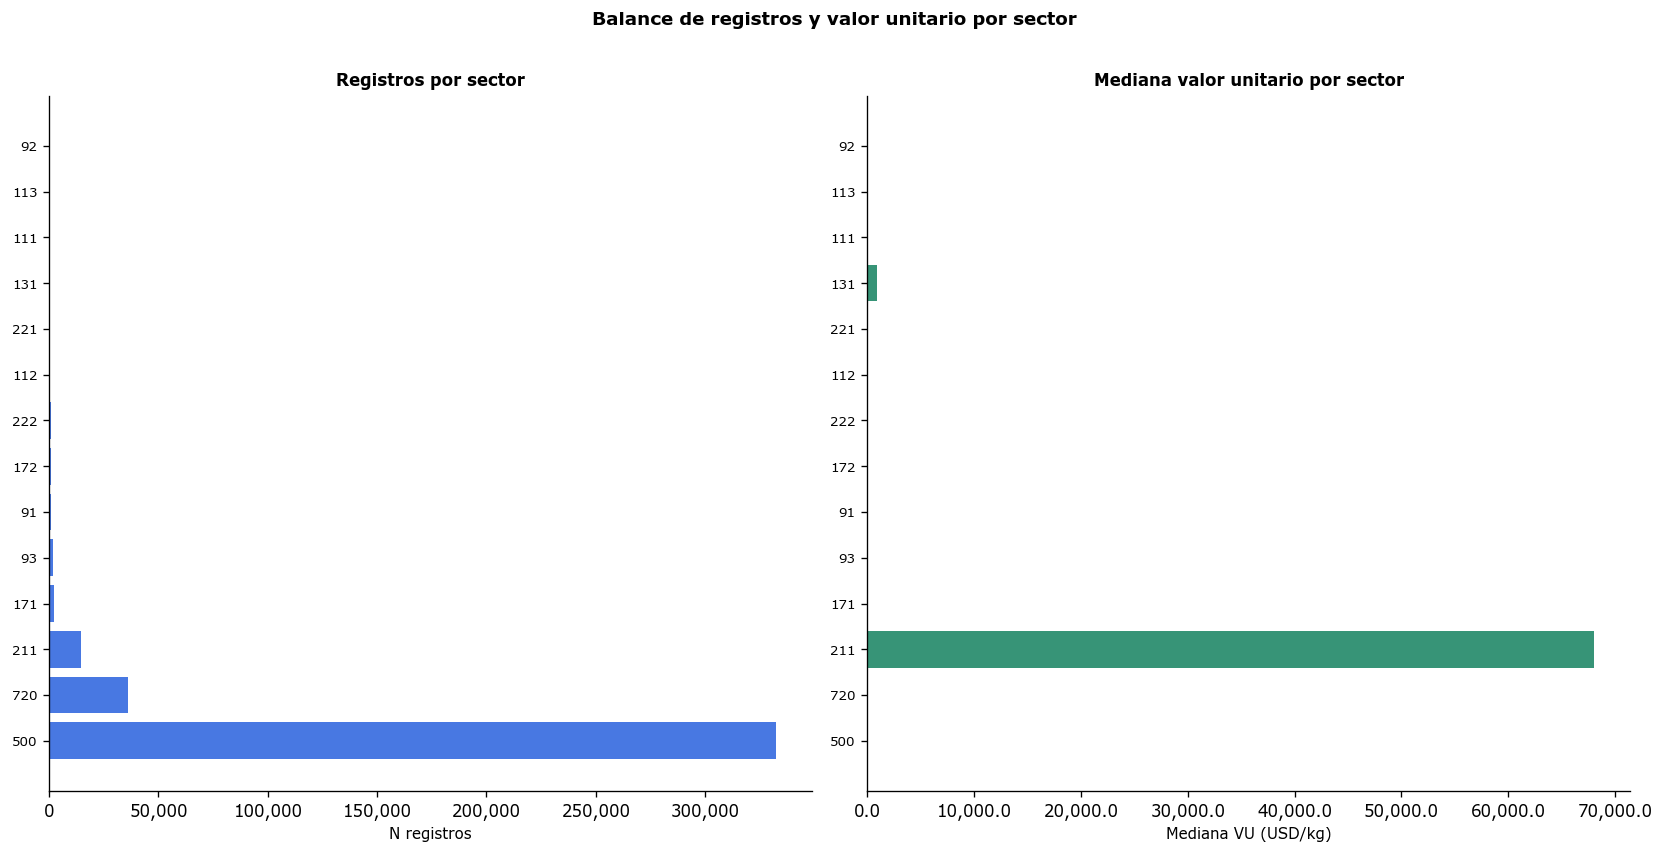

2026-05-08 19:46:49 | INFO | Balance por sector guardado: fig_balance_sector.png


In [21]:
# ── Balance por SECTOR ────────────────────────────────────────────────────────
balance_sector = (
    df.groupby('SECTOR')[COL_V]
    .agg(['count', 'median', 'std'])
    .rename(columns={'count': 'N', 'median': 'Mediana_VU', 'std': 'Desv_VU'})
    .round(3)
    .sort_values('N', ascending=False)
)
balance_sector['N_%'] = (100 * balance_sector['N'] / balance_sector['N'].sum()).round(2)

print('BALANCE POR SECTOR (variable objetivo: MTO_VALOR_UNTARIO_V)')
print('=' * 65)
print(balance_sector.to_string())

# Gráfico de barras horizontales
fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(balance_sector) * 0.5)))

y_pos   = range(len(balance_sector))
etqs    = [str(s)[:35] for s in balance_sector.index]

axes[0].barh(y_pos, balance_sector['N'], color='#1a56db', alpha=0.8)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(etqs, fontsize=8)
axes[0].set_xlabel('N registros')
axes[0].set_title('Registros por sector', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[1].barh(y_pos, balance_sector['Mediana_VU'], color='#057a55', alpha=0.8)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(etqs, fontsize=8)
axes[1].set_xlabel('Mediana VU (USD/kg)')
axes[1].set_title('Mediana valor unitario por sector', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.1f}'))

plt.suptitle('Balance de registros y valor unitario por sector',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_balance_sector.png', dpi=120, bbox_inches='tight')
plt.show()
log.info('Balance por sector guardado: fig_balance_sector.png')

### 2.2 Correlaciones entre variables numéricas

MATRIZ DE CORRELACION GLOBAL — PEARSON, escala log
          log_FOB  log_PESO  log_VU
log_FOB     1.000     0.650   0.282
log_PESO    0.650     1.000  -0.526
log_VU      0.282    -0.526   1.000

MATRIZ DE CORRELACION GLOBAL — SPEARMAN, escala log
          log_FOB  log_PESO  log_VU
log_FOB     1.000     0.616   0.156
log_PESO    0.616     1.000  -0.516
log_VU      0.156    -0.516   1.000

Nota metodologica:
- La correlacion global se mantiene solo como referencia exploratoria.
- No se usa como explicacion principal porque mezcla subpartidas con escalas distintas.
- Como VU = FOB_DOLAR / PESO_NETO, la interpretacion no debe ser causal.


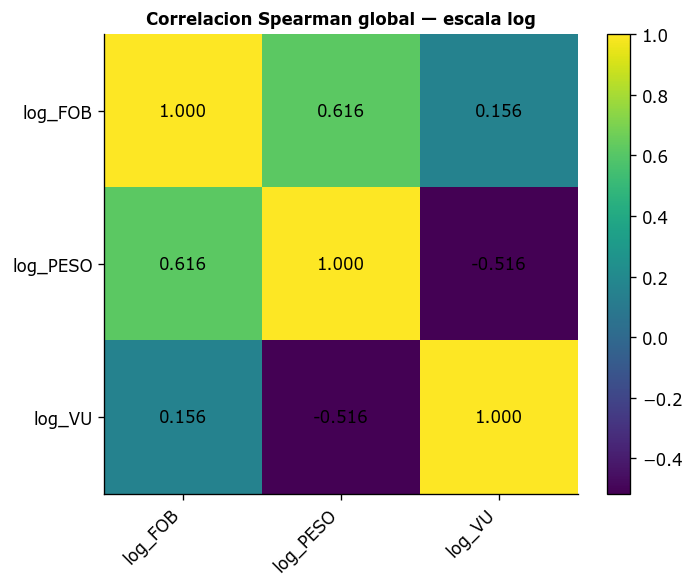

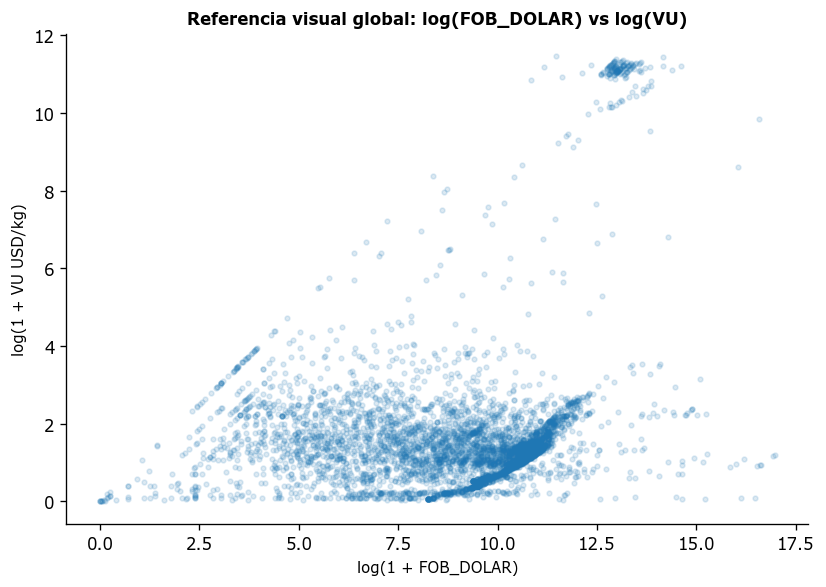


CORRELACION SPEARMAN POR TOP 10 SUBPARTIDAS SEGUN FOB_DOLAR
                                                                       NUM_SPN_R REGISTROS   FOB_DOLAR_TOTAL  corr_log_FOB_log_PESO  corr_log_FOB_log_VU  corr_log_PESO_log_VU
                                2603000000-MINERALES DE COBRE Y SUS CONCENTRADOS     1,297 15,487,877,217.01                  0.916                0.350                 0.064
                                     7108120000-ORO EN LAS DEMAS FORMAS EN BRUTO    14,491 10,925,238,241.87                  0.760                0.159                -0.373
                     7403110000-CATODOS Y SECCIONES DE CATODOS DE COBRE REFINADO       948  2,270,523,058.71                  0.957                0.146                -0.048
810400000-ARANDANOS ROJOS, MIRTILOS Y DEMAS FRUTOS DEL GENERO VACCINIUM, FRESCOS    27,373  2,103,763,319.42                  0.746                0.374                -0.194
                2601110000-MINERALES DE HIERRO Y SUS CONCENTRADO

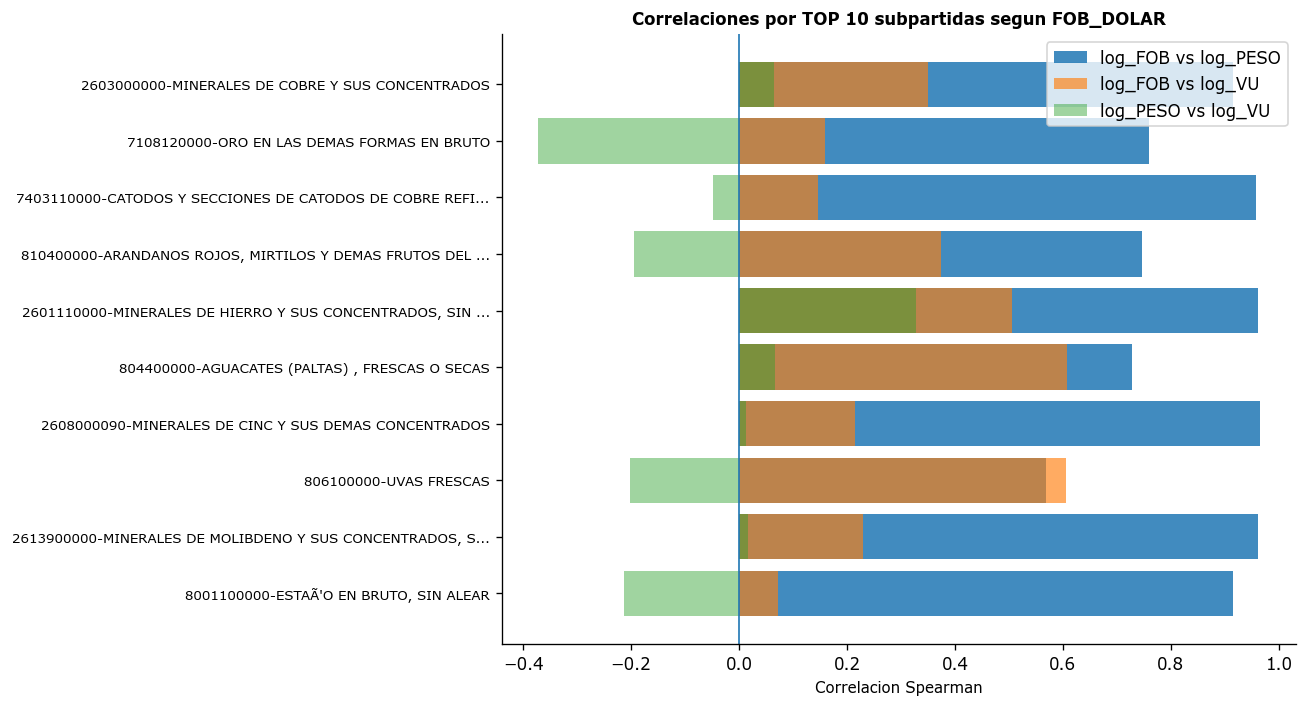

2026-05-08 20:00:38 | INFO | Correlaciones e interpretacion por TOP 3 subpartidas generadas: interpretacion_correlaciones_top3_subpartidas.txt



CORRELACION SPEARMAN POR ADUANA
                  ADUANA REGISTROS   FOB_DOLAR_TOTAL  corr_log_FOB_log_PESO  corr_log_FOB_log_VU  corr_log_PESO_log_VU
AEREA Y POSTAL EX - IAAC    81,926 11,510,751,760.93                  0.329                0.482                -0.492
     MARITIMA DEL CALLAO   153,658 11,353,748,160.96                  0.836                0.060                -0.397
     MOLLENDO - MATARANI     4,004  8,443,701,320.46                  0.876                0.543                 0.131
                     ILO     1,229  4,499,318,312.19                  0.873                0.188                -0.079
                   PISCO    30,355  2,708,562,718.23                 -0.004                0.719                -0.584
                CHIMBOTE     3,487  2,357,382,993.32                  0.459                0.525                -0.406
               SALAVERRY    25,015  1,948,140,981.30                  0.308                0.650                -0.389
               

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# CORRELACIONES RELEVANTES PARA VALOR UNITARIO
# Enfoque:
#   1. Correlacion global solo como referencia exploratoria.
#   2. Correlacion por TOP 10 subpartidas segun FOB_DOLAR.
#   3. Correlacion por ADUANA.
#   4. Interpretacion automatica centrada en TOP 3 subpartidas.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


# ─────────────────────────────────────────────────────────────────────────────
# 1. Validacion de columnas requeridas
# ─────────────────────────────────────────────────────────────────────────────

columnas_requeridas = [
    'FOB_DOLAR',
    'PESO_NETO',
    'NUM_SPN_R',
    'ADUANA',
    COL_V
]

faltantes = [
    col for col in columnas_requeridas
    if col not in df.columns
]

if faltantes:
    raise ValueError(f'Columnas faltantes en df_model: {faltantes}')


# ─────────────────────────────────────────────────────────────────────────────
# 2. Preparar base limpia
# ─────────────────────────────────────────────────────────────────────────────

df_corr_base = df[
    [
        'NUM_SPN_R',
        'ADUANA',
        'FOB_DOLAR',
        'PESO_NETO',
        COL_V
    ]
].copy()

df_corr_base['FOB_DOLAR'] = pd.to_numeric(
    df_corr_base['FOB_DOLAR'],
    errors='coerce'
)

df_corr_base['PESO_NETO'] = pd.to_numeric(
    df_corr_base['PESO_NETO'],
    errors='coerce'
)

df_corr_base[COL_V] = pd.to_numeric(
    df_corr_base[COL_V],
    errors='coerce'
)

df_corr_base = df_corr_base.dropna(
    subset=[
        'NUM_SPN_R',
        'ADUANA',
        'FOB_DOLAR',
        'PESO_NETO',
        COL_V
    ]
).copy()

df_corr_base = df_corr_base[
    (df_corr_base['FOB_DOLAR'] > 0) &
    (df_corr_base['PESO_NETO'] > 0) &
    (df_corr_base[COL_V] > 0)
].copy()


# ─────────────────────────────────────────────────────────────────────────────
# 3. Variables logaritmicas
# ─────────────────────────────────────────────────────────────────────────────

df_corr_base['log_FOB'] = np.log1p(df_corr_base['FOB_DOLAR'])
df_corr_base['log_PESO'] = np.log1p(df_corr_base['PESO_NETO'])
df_corr_base['log_VU'] = np.log1p(df_corr_base[COL_V])

cols_corr = [
    'log_FOB',
    'log_PESO',
    'log_VU'
]


# ─────────────────────────────────────────────────────────────────────────────
# 4. Correlacion global: solo referencia metodologica
# ─────────────────────────────────────────────────────────────────────────────

corr_pearson = df_corr_base[cols_corr].corr(method='pearson').round(3)
corr_spearman = df_corr_base[cols_corr].corr(method='spearman').round(3)

print('MATRIZ DE CORRELACION GLOBAL — PEARSON, escala log')
print('=' * 80)
print(corr_pearson.to_string())

print()
print('MATRIZ DE CORRELACION GLOBAL — SPEARMAN, escala log')
print('=' * 80)
print(corr_spearman.to_string())

print()
print('Nota metodologica:')
print('- La correlacion global se mantiene solo como referencia exploratoria.')
print('- No se usa como explicacion principal porque mezcla subpartidas con escalas distintas.')
print('- Como VU = FOB_DOLAR / PESO_NETO, la interpretacion no debe ser causal.')


# ─────────────────────────────────────────────────────────────────────────────
# 5. Heatmap global Spearman sin seaborn
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 5))

matriz = corr_spearman.values
im = ax.imshow(matriz, aspect='auto')

ax.set_xticks(range(len(cols_corr)))
ax.set_yticks(range(len(cols_corr)))
ax.set_xticklabels(cols_corr, rotation=45, ha='right')
ax.set_yticklabels(cols_corr)

for i in range(len(cols_corr)):
    for j in range(len(cols_corr)):
        ax.text(
            j,
            i,
            f'{matriz[i, j]:.3f}',
            ha='center',
            va='center'
        )

ax.set_title(
    'Correlacion Spearman global — escala log',
    fontweight='bold'
)

fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig(
    'fig_correlacion_global_spearman.png',
    dpi=120,
    bbox_inches='tight'
)
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 6. Scatter global log_FOB vs log_VU como referencia visual
# ─────────────────────────────────────────────────────────────────────────────

muestra = df_corr_base.sample(
    min(5_000, len(df_corr_base)),
    random_state=42
)

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    muestra['log_FOB'],
    muestra['log_VU'],
    alpha=0.15,
    s=8
)

ax.set_xlabel('log(1 + FOB_DOLAR)')
ax.set_ylabel('log(1 + VU USD/kg)')
ax.set_title(
    'Referencia visual global: log(FOB_DOLAR) vs log(VU)',
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(
    'fig_scatter_log_fob_log_vu.png',
    dpi=120,
    bbox_inches='tight'
)
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 7. Correlacion por TOP 10 subpartidas segun FOB_DOLAR
# ─────────────────────────────────────────────────────────────────────────────

TOP_N_SUBPARTIDAS = 10

top_subpartidas = (
    df_corr_base
    .groupby('NUM_SPN_R', as_index=False)
    .agg(
        FOB_DOLAR_TOTAL=('FOB_DOLAR', 'sum'),
        REGISTROS=('NUM_SPN_R', 'size')
    )
    .sort_values('FOB_DOLAR_TOTAL', ascending=False)
    .head(TOP_N_SUBPARTIDAS)
)

subpartidas_top = top_subpartidas['NUM_SPN_R'].tolist()

resultados_corr_spn = []

for num_spn_r, df_spn in df_corr_base[
    df_corr_base['NUM_SPN_R'].isin(subpartidas_top)
].groupby('NUM_SPN_R'):

    if len(df_spn) < 30:
        continue

    corr_spn = df_spn[cols_corr].corr(method='spearman')

    resultados_corr_spn.append({
        'NUM_SPN_R': num_spn_r,
        'REGISTROS': len(df_spn),
        'FOB_DOLAR_TOTAL': df_spn['FOB_DOLAR'].sum(),
        'corr_log_FOB_log_PESO': corr_spn.loc['log_FOB', 'log_PESO'],
        'corr_log_FOB_log_VU': corr_spn.loc['log_FOB', 'log_VU'],
        'corr_log_PESO_log_VU': corr_spn.loc['log_PESO', 'log_VU']
    })

df_corr_spn = (
    pd.DataFrame(resultados_corr_spn)
    .round(3)
    .sort_values('FOB_DOLAR_TOTAL', ascending=False)
    .reset_index(drop=True)
)

print()
print('CORRELACION SPEARMAN POR TOP 10 SUBPARTIDAS SEGUN FOB_DOLAR')
print('=' * 110)

df_corr_spn_print = df_corr_spn.copy()

df_corr_spn_print['FOB_DOLAR_TOTAL'] = df_corr_spn_print['FOB_DOLAR_TOTAL'].map(
    lambda x: f'{x:,.2f}'
)

df_corr_spn_print['REGISTROS'] = df_corr_spn_print['REGISTROS'].map(
    lambda x: f'{x:,.0f}'
)

print(df_corr_spn_print.to_string(index=False))


# ─────────────────────────────────────────────────────────────────────────────
# 8. Grafico de correlaciones por TOP 10 subpartidas
# ─────────────────────────────────────────────────────────────────────────────

if not df_corr_spn.empty:

    df_plot_spn = df_corr_spn.sort_values(
        'FOB_DOLAR_TOTAL',
        ascending=True
    ).copy()

    etiquetas_spn = [
        str(x)[:55] + '...' if len(str(x)) > 55 else str(x)
        for x in df_plot_spn['NUM_SPN_R']
    ]

    y = range(len(df_plot_spn))

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.barh(
        y,
        df_plot_spn['corr_log_FOB_log_PESO'],
        alpha=0.85,
        label='log_FOB vs log_PESO'
    )

    ax.barh(
        y,
        df_plot_spn['corr_log_FOB_log_VU'],
        alpha=0.65,
        label='log_FOB vs log_VU'
    )

    ax.barh(
        y,
        df_plot_spn['corr_log_PESO_log_VU'],
        alpha=0.45,
        label='log_PESO vs log_VU'
    )

    ax.axvline(
        0,
        linewidth=1
    )

    ax.set_yticks(y)
    ax.set_yticklabels(etiquetas_spn, fontsize=8)
    ax.set_xlabel('Correlacion Spearman')
    ax.set_title(
        'Correlaciones por TOP 10 subpartidas segun FOB_DOLAR',
        fontweight='bold'
    )

    ax.legend()

    plt.tight_layout()
    plt.savefig(
        'fig_corr_top10_subpartidas.png',
        dpi=120,
        bbox_inches='tight'
    )
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 9. Correlacion por ADUANA
# ─────────────────────────────────────────────────────────────────────────────

resultados_corr_aduana = []

for aduana, df_aduana in df_corr_base.groupby('ADUANA'):

    if len(df_aduana) < 30:
        continue

    corr_aduana = df_aduana[cols_corr].corr(method='spearman')

    resultados_corr_aduana.append({
        'ADUANA': aduana,
        'REGISTROS': len(df_aduana),
        'FOB_DOLAR_TOTAL': df_aduana['FOB_DOLAR'].sum(),
        'corr_log_FOB_log_PESO': corr_aduana.loc['log_FOB', 'log_PESO'],
        'corr_log_FOB_log_VU': corr_aduana.loc['log_FOB', 'log_VU'],
        'corr_log_PESO_log_VU': corr_aduana.loc['log_PESO', 'log_VU']
    })

df_corr_aduana = (
    pd.DataFrame(resultados_corr_aduana)
    .round(3)
    .sort_values('FOB_DOLAR_TOTAL', ascending=False)
    .reset_index(drop=True)
)

print()
print('CORRELACION SPEARMAN POR ADUANA')
print('=' * 110)

df_corr_aduana_print = df_corr_aduana.copy()

df_corr_aduana_print['FOB_DOLAR_TOTAL'] = df_corr_aduana_print['FOB_DOLAR_TOTAL'].map(
    lambda x: f'{x:,.2f}'
)

df_corr_aduana_print['REGISTROS'] = df_corr_aduana_print['REGISTROS'].map(
    lambda x: f'{x:,.0f}'
)

print(df_corr_aduana_print.to_string(index=False))


# ─────────────────────────────────────────────────────────────────────────────
# 10. Guardar resultados tabulares
# ─────────────────────────────────────────────────────────────────────────────

df_corr_spn.to_csv(
    'corr_spearman_top_subpartidas.csv',
    index=False,
    sep='|',
    encoding='utf-8-sig'
)

df_corr_aduana.to_csv(
    'corr_spearman_aduana.csv',
    index=False,
    sep='|',
    encoding='utf-8-sig'
)

print()
print('Archivos guardados:')
print('- corr_spearman_top_subpartidas.csv')
print('- corr_spearman_aduana.csv')


# ─────────────────────────────────────────────────────────────────────────────
# 11. Interpretacion automatica enfocada en TOP 3 subpartidas
# ─────────────────────────────────────────────────────────────────────────────

def interpretar_correlacion(valor: float) -> str:
    """
    Interpreta la magnitud y direccion de una correlacion.

    Args:
        valor (float): Valor de correlacion entre -1 y 1.

    Returns:
        str: Texto con fuerza y direccion de la relacion.
    """
    abs_valor = abs(valor)

    if abs_valor >= 0.80:
        fuerza = 'muy fuerte'
    elif abs_valor >= 0.60:
        fuerza = 'fuerte'
    elif abs_valor >= 0.40:
        fuerza = 'moderada'
    elif abs_valor >= 0.20:
        fuerza = 'debil'
    else:
        fuerza = 'muy debil o casi nula'

    if valor > 0:
        direccion = 'positiva'
    elif valor < 0:
        direccion = 'negativa'
    else:
        direccion = 'nula'

    return f'{fuerza} {direccion}'


def interpretar_subpartida_correlacion(fila: pd.Series) -> list:
    """
    Genera interpretacion textual para una subpartida especifica.

    Args:
        fila (pd.Series): Fila de df_corr_spn con correlaciones por subpartida.

    Returns:
        list: Lineas de texto interpretativo.
    """
    num_spn_r = fila['NUM_SPN_R']
    registros = fila['REGISTROS']
    fob_total = fila['FOB_DOLAR_TOTAL']

    corr_fob_peso = fila['corr_log_FOB_log_PESO']
    corr_fob_vu = fila['corr_log_FOB_log_VU']
    corr_peso_vu = fila['corr_log_PESO_log_VU']

    lineas = []

    lineas.append(f'Subpartida: {num_spn_r}')
    lineas.append(f'Registros analizados: {registros:,.0f}')
    lineas.append(f'FOB_DOLAR total: {fob_total:,.2f}')
    lineas.append('')

    lineas.append(
        f'- log_FOB vs log_PESO = {corr_fob_peso:.3f}: '
        f'relacion {interpretar_correlacion(corr_fob_peso)}.'
    )

    if corr_fob_peso >= 0.60:
        lineas.append(
            '  Interpretacion: el valor FOB tiende a crecer de forma consistente '
            'con el peso neto dentro de esta subpartida.'
        )
    elif corr_fob_peso <= -0.40:
        lineas.append(
            '  Interpretacion: existe una relacion inversa relevante entre FOB y peso. '
            'Este patron debe revisarse porque puede indicar operaciones especiales o valores atipicos.'
        )
    else:
        lineas.append(
            '  Interpretacion: el peso neto no explica de forma clara el FOB dentro de esta subpartida.'
        )

    lineas.append(
        f'- log_FOB vs log_VU = {corr_fob_vu:.3f}: '
        f'relacion {interpretar_correlacion(corr_fob_vu)}.'
    )

    if corr_fob_vu >= 0.40:
        lineas.append(
            '  Interpretacion: las operaciones de mayor FOB tienden a presentar mayor valor unitario.'
        )
    elif corr_fob_vu <= -0.40:
        lineas.append(
            '  Interpretacion: las operaciones de mayor FOB tienden a tener menor valor unitario.'
        )
    else:
        lineas.append(
            '  Interpretacion: el monto FOB no se asocia fuertemente con el valor unitario.'
        )

    lineas.append(
        f'- log_PESO vs log_VU = {corr_peso_vu:.3f}: '
        f'relacion {interpretar_correlacion(corr_peso_vu)}.'
    )

    if corr_peso_vu <= -0.40:
        lineas.append(
            '  Interpretacion: las operaciones con menor peso tienden a mostrar valores unitarios mas altos.'
        )
    elif corr_peso_vu >= 0.40:
        lineas.append(
            '  Interpretacion: las operaciones con mayor peso tambien tienden a mostrar mayor valor unitario.'
        )
    else:
        lineas.append(
            '  Interpretacion: el peso neto no tiene una asociacion fuerte con el valor unitario.'
        )

    lineas.append('')

    abs_corrs = {
        'log_FOB_vs_log_PESO': abs(corr_fob_peso),
        'log_FOB_vs_log_VU': abs(corr_fob_vu),
        'log_PESO_vs_log_VU': abs(corr_peso_vu)
    }

    relacion_principal = max(
        abs_corrs,
        key=abs_corrs.get
    )

    if relacion_principal == 'log_FOB_vs_log_PESO':
        lineas.append(
            'Conclusion: la relacion dominante en esta subpartida es FOB vs peso neto. '
            'Para detectar outliers, conviene revisar desviaciones del VU respecto '
            'a operaciones de peso comparable.'
        )
    elif relacion_principal == 'log_FOB_vs_log_VU':
        lineas.append(
            'Conclusion: la relacion dominante en esta subpartida es FOB vs valor unitario. '
            'Para detectar outliers, los registros con FOB alto y VU alto merecen revision prioritaria.'
        )
    else:
        lineas.append(
            'Conclusion: la relacion dominante en esta subpartida es peso neto vs valor unitario. '
            'Para detectar outliers, se debe revisar si operaciones de bajo peso concentran VU extremos.'
        )

    return lineas


# ─────────────────────────────────────────────────────────────────────────────
# 12. Construir texto interpretativo
# ─────────────────────────────────────────────────────────────────────────────

if df_corr_spn.empty:
    raise ValueError(
        'df_corr_spn esta vacio. No hay correlaciones por subpartida para interpretar.'
    )

top3_subpartidas_corr = (
    df_corr_spn
    .sort_values('FOB_DOLAR_TOTAL', ascending=False)
    .head(3)
    .copy()
)

corr_global_fob_peso = corr_spearman.loc['log_FOB', 'log_PESO']
corr_global_fob_vu = corr_spearman.loc['log_FOB', 'log_VU']
corr_global_peso_vu = corr_spearman.loc['log_PESO', 'log_VU']

interpretacion = []

interpretacion.append('INTERPRETACION AUTOMATICA — CORRELACIONES POR SUBPARTIDA')
interpretacion.append('=' * 90)
interpretacion.append('')

interpretacion.append('1. Nota metodologica')
interpretacion.append('-' * 90)
interpretacion.append(
    'La correlacion global se mantiene solo como referencia exploratoria. '
    'No se usa como explicacion principal porque mezcla productos con escalas, '
    'precios y patrones comerciales diferentes.'
)
interpretacion.append(
    'La interpretacion principal se realiza sobre las 3 subpartidas con mayor '
    'FOB_DOLAR, respetando la heterogeneidad del valor unitario por producto.'
)
interpretacion.append(
    'Ademas, VU se deriva de FOB_DOLAR / PESO_NETO; por ello, estas correlaciones '
    'no deben interpretarse como causalidad, sino como evidencia exploratoria.'
)

interpretacion.append('')
interpretacion.append('2. Referencia global no concluyente')
interpretacion.append('-' * 90)
interpretacion.append(
    f'Globalmente, log_FOB vs log_PESO = {corr_global_fob_peso:.3f}, '
    f'log_FOB vs log_VU = {corr_global_fob_vu:.3f}, '
    f'y log_PESO vs log_VU = {corr_global_peso_vu:.3f}.'
)
interpretacion.append(
    'Estos valores ayudan a contextualizar el dataset completo, pero la lectura '
    'relevante para outliers se realiza por subpartida.'
)

interpretacion.append('')
interpretacion.append('3. Analisis de las 3 principales subpartidas por FOB_DOLAR')
interpretacion.append('-' * 90)

for posicion, (_, fila) in enumerate(top3_subpartidas_corr.iterrows(), start=1):

    interpretacion.append('')
    interpretacion.append(f'3.{posicion}. Top {posicion} por FOB_DOLAR')
    interpretacion.append('-' * 90)

    lineas_subpartida = interpretar_subpartida_correlacion(
        fila
    )

    interpretacion.extend(
        lineas_subpartida
    )

interpretacion.append('')
interpretacion.append('4. Conclusion general del bloque')
interpretacion.append('-' * 90)
interpretacion.append(
    'La evidencia principal debe leerse por subpartida. Si una subpartida muestra '
    'alta correlacion entre FOB y peso, el valor FOB responde principalmente al volumen fisico. '
    'Si muestra mayor relacion entre FOB y VU, el precio unitario tiene mayor peso en el monto total.'
)
interpretacion.append(
    'Para la deteccion de outliers, esto justifica que las reglas IQR, log1p, '
    'winsorizacion o Isolation Forest se apliquen respetando NUM_SPN_R. '
    'Un valor unitario extremo solo tiene sentido si se compara contra productos equivalentes.'
)


# ─────────────────────────────────────────────────────────────────────────────
# 13. Imprimir y guardar interpretacion
# ─────────────────────────────────────────────────────────────────────────────

texto_interpretacion = '\n'.join(
    interpretacion
)

print()
print(texto_interpretacion)

ruta_interpretacion = 'interpretacion_correlaciones_top3_subpartidas.txt'

with open(ruta_interpretacion, 'w', encoding='utf-8') as archivo:
    archivo.write(texto_interpretacion)

print()
print(f'Interpretacion guardada en: {ruta_interpretacion}')

try:
    log.info(
        'Correlaciones e interpretacion por TOP 3 subpartidas generadas: %s',
        ruta_interpretacion
    )
except NameError:
    pass

### 2.3 Distribución del VU con winsorización (FE básico)

Winsorización P5=0.237 · P95=51.002 USD/kg
Registros afectados por corte inferior : 19,507
Registros afectados por corte superior : 19,513
Eje X visual para VU original          : 0 a 51.002 USD/kg
Nota: el ajuste del eje X es solo visual; no modifica el cálculo de percentiles.


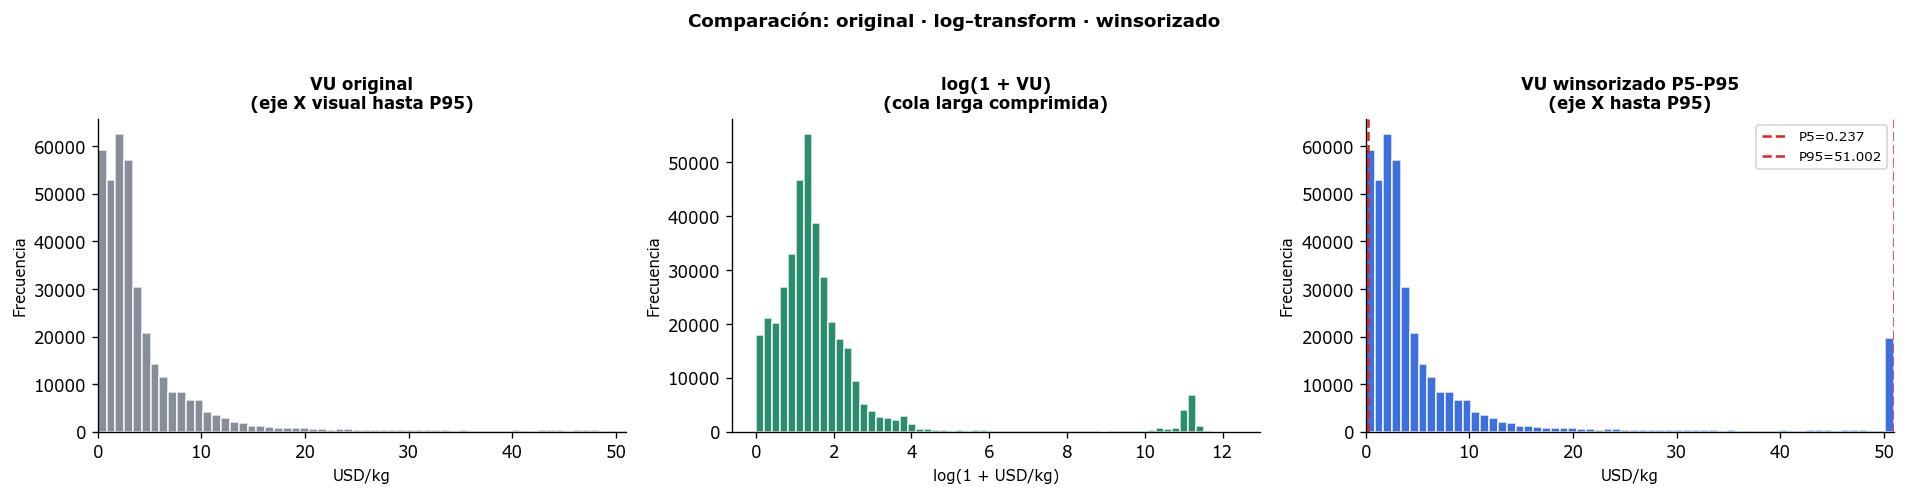

2026-05-08 20:05:17 | INFO | Gráfico winsorización guardado: fig_winsor_transform.png


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# Winsorización P5-P95 + comparación visual
# Objetivo:
#   Comparar VU original, log1p(VU) y VU winsorizado.
#   El eje X de VU original se ajusta visualmente hasta P95 para que no se
#   distorsione por valores extremos.
# ─────────────────────────────────────────────────────────────────────────────

datos_orig = df[COL_V].dropna()
datos_orig = datos_orig[datos_orig > 0]

# ── Percentiles de winsorización ─────────────────────────────────────────────
p5 = datos_orig.quantile(0.05)
p95 = datos_orig.quantile(0.95)

vu_wins = datos_orig.clip(
    lower=p5,
    upper=p95
)

print(f'Winsorización P5={p5:,.3f} · P95={p95:,.3f} USD/kg')
print(f'Registros afectados por corte inferior : {(datos_orig < p5).sum():,}')
print(f'Registros afectados por corte superior : {(datos_orig > p95).sum():,}')
print(f'Eje X visual para VU original          : 0 a {p95:,.3f} USD/kg')
print('Nota: el ajuste del eje X es solo visual; no modifica el cálculo de percentiles.')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ─────────────────────────────────────────────────────────────────────────────
# 1. VU original con eje X visual hasta P95
# ─────────────────────────────────────────────────────────────────────────────
axes[0].hist(
    datos_orig,
    bins=60,
    range=(0, p95),
    color='#6b7280',
    edgecolor='white',
    alpha=0.8
)

axes[0].set_xlim(0, p95)

axes[0].set_title(
    'VU original\n(eje X visual hasta P95)',
    fontweight='bold'
)

axes[0].set_xlabel('USD/kg')
axes[0].set_ylabel('Frecuencia')

# ─────────────────────────────────────────────────────────────────────────────
# 2. log1p(VU)
# ─────────────────────────────────────────────────────────────────────────────
axes[1].hist(
    np.log1p(datos_orig),
    bins=60,
    color='#057a55',
    edgecolor='white',
    alpha=0.85
)

axes[1].set_title(
    'log(1 + VU)\n(cola larga comprimida)',
    fontweight='bold'
)

axes[1].set_xlabel('log(1 + USD/kg)')
axes[1].set_ylabel('Frecuencia')

# ─────────────────────────────────────────────────────────────────────────────
# 3. VU winsorizado P5-P95
# ─────────────────────────────────────────────────────────────────────────────
axes[2].hist(
    vu_wins,
    bins=60,
    range=(0, p95),
    color='#1a56db',
    edgecolor='white',
    alpha=0.85
)

axes[2].axvline(
    p5,
    color='#e02424',
    linestyle='--',
    linewidth=1.5,
    label=f'P5={p5:,.3f}'
)

axes[2].axvline(
    p95,
    color='#e02424',
    linestyle='--',
    linewidth=1.5,
    label=f'P95={p95:,.3f}'
)

axes[2].set_xlim(0, p95)

axes[2].set_title(
    'VU winsorizado P5-P95\n(eje X hasta P95)',
    fontweight='bold'
)

axes[2].set_xlabel('USD/kg')
axes[2].set_ylabel('Frecuencia')
axes[2].legend(fontsize=8)

plt.suptitle(
    'Comparación: original · log-transform · winsorizado',
    fontsize=11,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    'fig_winsor_transform.png',
    dpi=120,
    bbox_inches='tight'
)

plt.show()

log.info('Gráfico winsorización guardado: fig_winsor_transform.png')

---
## Sección 3 — Riesgos
### 3.1 Desbalance — subpartidas excluidas (< 36 reg/año)

In [35]:
# ── Subpartidas que cumplen el umbral vs excluidas ────────────────────────────
conteo = (
    df.groupby([COL_C, COL_R])[COL_V]
    .count()
    .reset_index(name='N')
)
aptas    = conteo[conteo['N'] >= UMBRAL_ANUAL]
excluidas= conteo[conteo['N'] <  UMBRAL_ANUAL]

total_sp  = conteo[COL_R].nunique()
n_aptas   = aptas[COL_R].nunique()
n_excl    = excluidas[COL_R].nunique()

print('=' * 65)
print('  DESBALANCE — SUBPARTIDAS')
print('=' * 65)
print(f'  Umbral                          : {UMBRAL_ANUAL} reg/año (≈ 3/mes)')
print(f'  Total subpartidas               : {total_sp}')
print(f'  Aptas para análisis (>= {UMBRAL_ANUAL})    : {n_aptas} ({100*n_aptas/total_sp:.1f}%)')
print(f'  Excluidas (<  {UMBRAL_ANUAL})              : {n_excl} ({100*n_excl/total_sp:.1f}%)')

if not excluidas.empty:
    print(f'\n  DETALLE EXCLUIDAS:')
    print(f'  {"AÑO":<8} {"N":>5}  SUBPARTIDA')
    print(f'  {"-"*8} {"-"*5}  {"-"*50}')
    for _, row in excluidas.sort_values('N').iterrows():
        print(f'  {row[COL_C]!s:<8} {row["N"]:>5}  {str(row[COL_R])[:55]}')

# Concentración: % de registros cubiertos por top 10 partidas
top10_n  = df.groupby(COL_R)[COL_V].count().nlargest(10).sum()
pct_top10= 100 * top10_n / len(df)
print(f'\n  Concentración: TOP 10 subpartidas acaparan el {pct_top10:.1f}% de los registros')

log.info('Análisis de desbalance completado')

2026-05-08 20:05:22 | INFO | Análisis de desbalance completado


  DESBALANCE — SUBPARTIDAS
  Umbral                          : 36 reg/año (≈ 3/mes)
  Total subpartidas               : 786
  Aptas para análisis (>= 36)    : 371 (47.2%)
  Excluidas (<  36)              : 415 (52.8%)

  DETALLE EXCLUIDAS:
  AÑO          N  SUBPARTIDA
  -------- -----  --------------------------------------------------
  2024         1  909211000-SEMILLAS DE CILANTRO PARA LA SIEMBRA, SIN TRI
  2024         1  1001910090-MORCAJO PARA LA SIEMBRA
  2024         1  1209911000-SEMILLAS CEBOLLAS, PUERROS (POROS), AJOS Y D
  2024         1  1209300000-SEMILLAS DE PLANTAS HERBACEAS UTILIZADAS PRI
  2024         1  1209913000-SEMILLAS DE ZANAHORIA (DAUCUS CAROTA), PARA 
  2024         1  7005219000-DEMAS VIDRIOS SIN ARMAR, COLOREADOS EN LA MA
  2024         1  801320000-NUECES DEL MARAÃ'ON (MEREY, CAJAUIL, ANACARDO
  2024         1  7010200000-TAPONES, TAPAS Y DEMAS DISPOSITIVOS DE CIERR
  2024         1  810500000-KIWIS FRESCOS
  2024         1  6812993000-CUERDAS Y CORDONES, 

### 3.2 Leakage · Drift · Sesgo

In [36]:
print('=' * 65)
print('  RIESGOS — LEAKAGE / DRIFT / SESGO')
print('=' * 65)

# ── LEAKAGE ───────────────────────────────────────────────────────────────────
print('\n  [LEAKAGE]')
print('  MTO_VALOR_UNTARIO_V = FOB/PESO calculado en SQL, sin usar ES_OUTLIER.')
print('  ES_OUTLIER se asigna en Python post-carga → no hay fuga train/test.')
print('  Riesgo residual: contaminación=0.05 fija; si la tasa real difiere,')
print('  la sensibilidad del modelo varía. Controlar con validación temporal.')

# ── DRIFT ─────────────────────────────────────────────────────────────────────
print('\n  [DRIFT]')
mediana_anual = df.groupby(COL_C)[COL_V].median().round(3)
if len(mediana_anual) > 1:
    drift_max = abs(mediana_anual.pct_change().dropna()).max() * 100
    nivel = 'ALTO' if drift_max > 30 else ('MODERADO' if drift_max > 10 else 'BAJO')
    print(f'  Variación máxima de mediana entre años : {drift_max:.1f}% — {nivel}')
    print(f'  Mediana por año: {mediana_anual.to_dict()}')
else:
    print('  Un solo año disponible — drift no evaluable.')
    print('  Con FEC_DECLARACION: evaluar drift mensual dentro del año.')

# ── SESGO por sector ──────────────────────────────────────────────────────────
print('\n  [SESGO]')
skew_global = df[COL_V].skew()
print(f'  Asimetría global (skew) : {skew_global:.3f}')
if abs(skew_global) > 1:
    print('  Distribución fuertemente sesgada a la derecha.')
    print('  → Transformación log recomendada antes de entrenar modelos basados en distancia.')

skew_sector = df.groupby('SECTOR')[COL_V].skew().round(3).sort_values(ascending=False)
print('\n  Asimetría por sector:')
for sector, sk in skew_sector.items():
    alerta = ' ← ALTO' if abs(sk) > 2 else ''
    print(f'    {str(sector)[:40]:<40} skew={sk:>7.3f}{alerta}')

print('\n' + '=' * 65)
log.info('Análisis de riesgos Parte 2 completado')

2026-05-08 20:05:24 | INFO | Análisis de riesgos Parte 2 completado


  RIESGOS — LEAKAGE / DRIFT / SESGO

  [LEAKAGE]
  MTO_VALOR_UNTARIO_V = FOB/PESO calculado en SQL, sin usar ES_OUTLIER.
  ES_OUTLIER se asigna en Python post-carga → no hay fuga train/test.
  Riesgo residual: contaminación=0.05 fija; si la tasa real difiere,
  la sensibilidad del modelo varía. Controlar con validación temporal.

  [DRIFT]
  Un solo año disponible — drift no evaluable.
  Con FEC_DECLARACION: evaluar drift mensual dentro del año.

  [SESGO]
  Asimetría global (skew) : 5.293
  Distribución fuertemente sesgada a la derecha.
  → Transformación log recomendada antes de entrenar modelos basados en distancia.

  Asimetría por sector:
    500                                      skew=117.093 ← ALTO
    720                                      skew= 98.956 ← ALTO
    93                                       skew= 31.586 ← ALTO
    91                                       skew= 24.134 ← ALTO
    172                                      skew= 20.099 ← ALTO
    112                

---
## Sección 4 — Conclusiones accionables
### Mínimo 2 decisiones concretas para el siguiente sprint

In [ ]:
# ── Resumen cuantitativo para las conclusiones ─────────────────────────────────
n_total      = len(df)
n_validos    = df[COL_V].notna().sum()
skew_g       = round(df[COL_V].skew(), 3)
p99_p50      = round(df[COL_V].quantile(0.99) / df[COL_V].median(), 1)
pct_excl_sp  = round(100 * n_excl / total_sp, 1)
pct_top10_r  = round(pct_top10, 1)

print('=' * 70)
print('  CONCLUSIONES ACCIONABLES — EDA PARTE 2')
print('  Said Leonardo Uceda Paredes | UNI FIIS | Maestría en IA | Mayo 2026')
print('=' * 70)

print(f'''
  ACCIONABLE 1 — Aplicar transformación log antes del modelado
  ─────────────────────────────────────────────────────────────
  Evidencia : skew global = {skew_g} (>1 = cola derecha larga).
               Ratio P99/P50 = {p99_p50}x → valores extremos distorsionan
               métricas de distancia (IQR, LOF, DBSCAN).
  Acción    : entrenar todos los modelos sobre log1p(MTO_VALOR_UNTARIO_V).
               Evaluar también winsorización P5–P95 como variante B (ablación).
  Riesgo    : reversar la transformación al reportar umbrales al negocio.
  Sprint    : implementar en Feature Engineering (Semana 4).
''')

print(f'''
  ACCIONABLE 2 — Excluir subpartidas con < {UMBRAL_ANUAL} registros/año del modelo
  ─────────────────────────────────────────────────────────────
  Evidencia : {n_excl} subpartidas ({pct_excl_sp}%) no alcanzan el mínimo estadístico
               de 3 registros/mes. IQR y percentiles son inestables con N < 36.
  Acción    : filtrar antes de entrenar; reportar aparte como "sin historial
               suficiente". Cuando se disponga de FEC_DECLARACION, recalcular
               con granularidad mensual (umbral = 3 reg/mes).
  Riesgo    : subpartidas nuevas o estacionales quedan sin cobertura.
  Sprint    : agregar flag IS_EXCLUIDA en pipeline (Semana 4).
''')

print(f'''
  ACCIONABLE 3 (adicional) — Estratificar análisis por sector
  ─────────────────────────────────────────────────────────────
  Evidencia : TOP 10 subpartidas concentran {pct_top10_r}% de los registros.
               Sesgo varía significativamente por sector (ver tabla arriba).
  Acción    : calibrar contamination del Isolation Forest por sector en lugar
               de usar 5% global; usar SECTOR como variable de agrupación.
  Riesgo    : sectores con pocos registros heredan el 5% global.
  Sprint    : evaluar en experimento A/B (Semana 4–5).
''')

print('=' * 70)
log.info('Conclusiones accionables generadas — 3 accionables')